In [10]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, learning_curve, train_test_split
from sklearn.linear_model import LogisticRegression

import numpy as np
from imblearn.over_sampling import SMOTE

def get_whole_df() -> pd.DataFrame:
    files = glob("combined_part_*.csv")
    df_list = []
    for file in files:
        df_list.append(pd.read_csv(file))

    return pd.concat(df_list, ignore_index=True)

df = get_whole_df()
print(df.shape) 



(692703, 79)


In [11]:
# strip whitespace from the headers first
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

# Replace infinities with a finite number (e.g. 0 or the column mean)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# # drop minor class:
df = df[df["Label"] != "Heartbleed"]

print(df["Label"].value_counts())

Label
BENIGN              416736
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Name: count, dtype: int64


In [12]:
binary_labels = []

for label in df["Label"]:
    if label == "BENIGN":
        binary_labels.append("BENIGN")
    else:
        binary_labels.append("ATTACK")

df["BinaryLabel"] = binary_labels

print(df["BinaryLabel"].value_counts())

BinaryLabel
BENIGN    416736
ATTACK    193745
Name: count, dtype: int64


In [13]:
X_binary = df.drop(["Label", "BinaryLabel"], axis=1)
y_binary = df["BinaryLabel"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

#smote = SMOTE(random_state=42)
#X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

Binary Model Results
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     38749
      BENIGN       1.00      1.00      1.00     83348

    accuracy                           1.00    122097
   macro avg       1.00      1.00      1.00    122097
weighted avg       1.00      1.00      1.00    122097



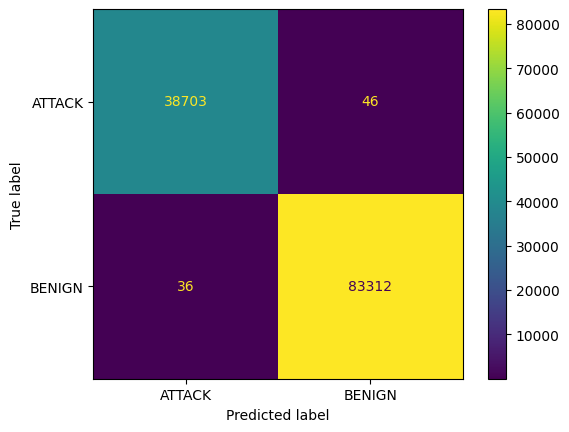

In [14]:
binary_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

binary_model.fit(X_train_bin, y_train_bin)

pred_binary = binary_model.predict(X_test_bin)

print("Binary Model Results")
print(classification_report(y_test_bin, pred_binary))

ConfusionMatrixDisplay.from_predictions(y_test_bin, pred_binary)
plt.show()

In [16]:
importance = pd.Series(
    binary_model.feature_importances_,
    index=X_binary.columns
).sort_values(ascending=False)

print(importance.head(10))

Avg Bwd Segment Size      0.106355
Max Packet Length         0.081118
Bwd Packet Length Max     0.077778
Packet Length Std         0.076677
Bwd Packet Length Std     0.065719
Packet Length Variance    0.059873
Average Packet Size       0.050445
Bwd Packet Length Mean    0.041514
Packet Length Mean        0.028881
Destination Port          0.027291
dtype: float64


In [17]:
train_pred = binary_model.predict(X_train_bin)
test_pred = binary_model.predict(X_test_bin)

train_acc = accuracy_score(y_train_bin, train_pred)
test_acc = accuracy_score(y_test_bin, test_pred)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9999447156335998
Test accuracy: 0.9993284028272603


In [18]:
scores = cross_val_score(binary_model, X_train_bin, y_train_bin, cv=5)

print(scores)
print("Mean accuracy:", scores.mean())

[0.99927311 0.99930383 0.99938573 0.99921169 0.99911954]
Mean accuracy: 0.9992587796913052


In [19]:
train_sizes, train_scores, test_scores = learning_curve(
    binary_model, X_train_bin, y_train_bin, cv=5
)

print("Train score:", np.mean(train_scores))
print("Test score:", np.mean(test_scores))

Train score: 0.9999789774170967
Test score: 0.9991506681412371


In [20]:
attack_df = df[df["Label"] != "BENIGN"].copy()

print(attack_df["Label"].value_counts())

X_attack = attack_df.drop("Label", axis=1)
y_attack = attack_df["Label"]

X_train_att, X_test_att, y_train_att, y_test_att = train_test_split(
    X_attack,
    y_attack,
    test_size=0.2,
    random_state=42,
    stratify=y_attack
)

Label
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Name: count, dtype: int64


In [21]:
attack_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

attack_model.fit(X_train_att, y_train_att)

y_pred_att = attack_model.predict(X_test_att)

print("Attack Type Model Results")
print(classification_report(y_test_att, y_pred_att))

ConfusionMatrixDisplay.from_predictions(y_test_att, y_pred_att)
plt.xticks(rotation=45)
plt.show()

ValueError: could not convert string to float: 'ATTACK'